In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
df = pd.read_csv("housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


# Making a working  dataset

In [5]:
df_work = df.copy()

In [6]:
df_work

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


# Preprocessing

In [7]:
df_work.shape

(20640, 10)

In [8]:
df_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
df_work['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [10]:
df_work.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [11]:
df_work['total_bedrooms'].isnull().sum()

np.int64(207)

In [12]:
df_work['total_bedrooms'] = df_work['total_bedrooms'].fillna(df_work['total_bedrooms'].mean())

In [13]:
df_work['total_bedrooms'].isnull().sum()

np.int64(0)

In [14]:
df_work['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [15]:
# This type of encoding is suitable only if there is two class, otherwise go for one hot encoding
# df_work['ocean_proximity'] = df_work['ocean_proximity'].map({
#     "<1H OCEAN": 0, 
#     "INLAND": 1,
#     "NEAR OCEAN": 2,
#     "NEAR BAY": 3,
#     "ISLAND":4    
# }) 

In [16]:
df_work= pd.get_dummies(df_work, columns=['ocean_proximity'], drop_first=True, dtype=int)

In [17]:
df_work

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1,0,0,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1,0,0,0


In [18]:
df_work.astype(int)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122,37,41,880,129,322,126,8,452600,0,0,1,0
1,-122,37,21,7099,1106,2401,1138,8,358500,0,0,1,0
2,-122,37,52,1467,190,496,177,7,352100,0,0,1,0
3,-122,37,52,1274,235,558,219,5,341300,0,0,1,0
4,-122,37,52,1627,280,565,259,3,342200,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121,39,25,1665,374,845,330,1,78100,1,0,0,0
20636,-121,39,18,697,150,356,114,2,77100,1,0,0,0
20637,-121,39,17,2254,485,1007,433,1,92300,1,0,0,0
20638,-121,39,18,1860,409,741,349,1,84700,1,0,0,0


# Scaling the value before train test split 

In [19]:
scaler = MinMaxScaler()

In [20]:
X = df_work.drop('median_house_value', axis = 1)
y = df_work['median_house_value']
y

0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64

In [21]:
X_scaled = scaler.fit_transform(X)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)

In [23]:
#Data Shape = 100%
#Inout feature 
# train_x = 80%
#test_x = 20%
#Output variables 
#y_train = 80 % 
#y_test = 20%
print(df_work.shape)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(20640, 13)
(16512, 12)
(4128, 12)
(16512,)
(4128,)


# Model Training and Architecture

In [24]:
model = Sequential([
    Input(shape=(X_train.shape[1],)), #input layer
    Dense(1000, activation="relu"), #First Hidden layer 
    Dense(500, activation="relu"), #second hidden layer 
    Dense(250, activation="relu"), #third hidden layer
    Dense(1, activation="linear") #Output
])

In [25]:
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
es = EarlyStopping(monitor='val_loss', mode='min',patience=50, restore_best_weights=True)

In [26]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), callbacks=[es], epochs=10, batch_size=50, verbose=1)

Epoch 1/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 23951190016.0000 - mae: 119044.1797 - val_loss: 9186846720.0000 - val_mae: 74647.7031
Epoch 2/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7360425472.0000 - mae: 65423.6758 - val_loss: 6332973056.0000 - val_mae: 62344.7500
Epoch 3/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5476212224.0000 - mae: 54728.8867 - val_loss: 5470452224.0000 - val_mae: 55591.9883
Epoch 4/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5187184640.0000 - mae: 52369.9219 - val_loss: 5273645056.0000 - val_mae: 53125.5078
Epoch 5/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5092641792.0000 - mae: 51665.5078 - val_loss: 5185452032.0000 - val_mae: 52037.6523
Epoch 6/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5036675584.0000 - mae: 51209.0977 - val_loss: 5129212928.0000 - val_mae: 51956.9414
Epoch 7/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4977786880.0000 - mae: 50807.5391 - val_loss: 5059923968.0000 - val_mae: 5

# Model Result and Prediction

In [27]:
y_pred = model.predict(X_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [28]:
y_pred

array([[ 73532.516],
       [107867.26 ],
       [274306.4  ],
       ...,
       [457086.72 ],
       [111910.086],
       [183457.31 ]], shape=(4128, 1), dtype=float32)

In [29]:
from sklearn.metrics import r2_score, classification_report, mean_absolute_error, mean_squared_error, mean_squared_log_error

In [30]:
print("mae: ", mean_absolute_error(y_test, y_pred))
print("mse: ", mean_squared_error(y_test, y_pred))
print("msle: ", mean_squared_log_error(y_test, y_pred))
print("Score: ", r2_score(y_test, y_pred))

mae:  50455.67522933132
mse:  4940484124.789098
msle:  0.11669755380392215
Score:  0.6229815113582913


In [31]:
history.history

{'loss': [23951190016.0,
  7360425472.0,
  5476212224.0,
  5187184640.0,
  5092641792.0,
  5036675584.0,
  4977786880.0,
  4917339136.0,
  4857117696.0,
  4810246656.0],
 'mae': [119044.1796875,
  65423.67578125,
  54728.88671875,
  52369.921875,
  51665.5078125,
  51209.09765625,
  50807.5390625,
  50444.80078125,
  50029.3203125,
  49788.265625],
 'val_loss': [9186846720.0,
  6332973056.0,
  5470452224.0,
  5273645056.0,
  5185452032.0,
  5129212928.0,
  5059923968.0,
  5047409664.0,
  5021225984.0,
  4940483584.0],
 'val_mae': [74647.703125,
  62344.75,
  55591.98828125,
  53125.5078125,
  52037.65234375,
  51956.94140625,
  50816.80078125,
  51778.37890625,
  52037.6875,
  50455.68359375]}

In [32]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
epochs = range(1, len(training_loss)+1)
epochs

range(1, 11)

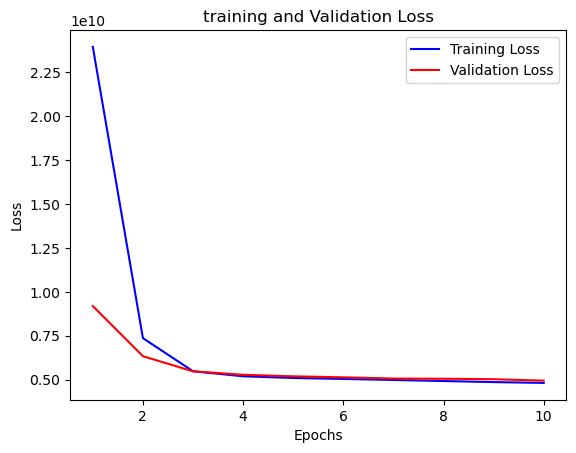

In [33]:
plt.plot(epochs, training_loss, 'b', label= 'Training Loss')
plt.plot(epochs, validation_loss, 'r', label= 'Validation Loss')

plt.title("training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [34]:
df_work.iloc[0]

longitude                       -122.2300
latitude                          37.8800
housing_median_age                41.0000
total_rooms                      880.0000
total_bedrooms                   129.0000
population                       322.0000
households                       126.0000
median_income                      8.3252
median_house_value            452600.0000
ocean_proximity_INLAND             0.0000
ocean_proximity_ISLAND             0.0000
ocean_proximity_NEAR BAY           1.0000
ocean_proximity_NEAR OCEAN         0.0000
Name: 0, dtype: float64

In [35]:
longitude                       -122.2300
latitude                          37.8800
housing_median_age                41.0000
total_rooms                      880.0000
total_bedrooms                   129.0000
population                       322.0000
households                       126.0000
median_income                      8.3252
ocean_proximity_NEAR BAY           1.0000


SyntaxError: invalid syntax (936109595.py, line 2)

# Predictive System

In [ ]:
def pred():
    pass